<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/olution_01_EDA_blood_transfusion_service_center.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
# 라이브러리 설치 (필요시)
# !pip install openml

import openml
import pandas as pd

# 데이터셋 ID(1464)로 데이터 가져오기
dataset = openml.datasets.get_dataset(1464)

# Pandas DataFrame 형태로 변환
X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format="dataframe", target=dataset.default_target_attribute
)

# 데이터 확인
df = pd.concat([X, y], axis=1)
df.head()

,V1,V2,V3,V4,Class
0,2,50,12500.0,98,2
1,0,13,3250.0,28,2
2,1,16,4000.0,35,2
3,2,20,5000.0,45,2
4,1,24,6000.0,77,1


In [52]:
from sklearn.datasets import fetch_openml

# name 또는 data_id로 호출 가능 (as_frame=True가 기본값)
blood_data = fetch_openml(data_id=1464, as_frame=True, parser='auto')

# 데이터와 타겟 합치기
df = blood_data.frame
df.head()

,V1,V2,V3,V4,Class
0,2,50,12500,98,2
1,0,13,3250,28,2
2,1,16,4000,35,2
3,2,20,5000,45,2
4,1,24,6000,77,1


In [53]:
import requests
import pandas as pd
from io import StringIO

# OpenML의 CSV 다운로드 직접 URL (ID 1464 기준)
url = "https://www.openml.org/data/get_csv/1586225/php0iVrYT"

# 데이터 요청
response = requests.get(url)

# StringIO를 사용하여 문자열을 파일 객체처럼 취급하여 Pandas로 읽기
df = pd.read_csv(StringIO(response.text))
df.head()

,V1,V2,V3,V4,Class
0,2,50,12500,98,2
1,0,13,3250,28,2
2,1,16,4000,35,2
3,2,20,5000,45,2
4,1,24,6000,77,1


# 🩸 헌혈 데이터셋 (Blood Transfusion Service Center Data Set)

## 1. 데이터 개요

본 데이터는 대만 신주시(Hsin-Chu City, Taiwan)에 위치한 헌혈 서비스 센터에서 수집된 데이터로,  
**이진 분류 문제(Classification Problem)** 를 다루는 데이터셋이다.

이 연구에서는 마케팅 분석 기법인 **RFM 모델(Recency, Frequency, Monetary)** 을 적용하기 위해 해당 데이터를 활용하였다.

---

## 2. 데이터 수집 배경

- 헌혈 서비스 센터는 약 **3개월마다 헌혈 버스를 대학에 파견**
- 해당 대학에서 헌혈 데이터를 주기적으로 수집
- 전체 데이터베이스에서 **748명의 헌혈자를 무작위로 추출**하여 분석에 사용

---

## 3. 변수(Feature) 정보

데이터는 4개의 독립 변수(V1 ~ V4)와 1개의 타겟 변수로 구성된다.

### 📊 변수 설명

| 변수명 | 변수명(영문) | 설명 |
|--------|-------------|------|
| V1 | Recency | 마지막 헌혈 이후 경과된 시간 (단위: 개월) |
| V2 | Frequency | 총 헌혈 횟수 |
| V3 | Monetary | 총 헌혈량 (단위: c.c.) |
| V4 | Time | 첫 헌혈 이후 경과된 시간 (단위: 개월) |

---

## 4. 타겟 변수 (Target Variable)

타겟 변수는 **2007년 3월 헌혈 여부**를 나타내는 이진 변수이다.

### 📌 정의

| 값 | 의미 |
|----|------|
| 1 | 헌혈하지 않음 |
| 2 | 헌혈함 |

👉 일부 데이터 정의에서는 다음과 같이 표현되기도 한다:

| 값 | 의미 |
|----|------|
| 0 | 헌혈하지 않음 |
| 1 | 헌혈함 |

---

## 5. 문제 정의

본 데이터셋의 목적은 다음과 같다:

> 과거 헌혈 이력을 기반으로  
> **미래(2007년 3월)의 헌혈 여부를 예측하는 것**

---

## 6. 분석 관점 (RFM 모델)

본 데이터는 고객 행동 분석에서 사용되는 **RFM 모델**을 확장한 구조를 가진다.

- **Recency (최근성)**: 얼마나 최근에 헌혈했는가  
- **Frequency (빈도)**: 얼마나 자주 헌혈했는가  
- **Monetary (수익성)**: 얼마나 많은 헌혈을 했는가  
- **Time (기간)**: 얼마나 오랜 기간 헌혈 활동을 했는가  



👉 이를 통해 헌혈자의 행동 패턴을 분석하고, 재헌혈 가능성을 예측할 수 있다.

In [54]:
import requests
import pandas as pd

url = "https://www.openml.org/data/get_csv/1586225/php0iVrYT"
file_name = "blood_transfusion.csv"

# 파일 다운로드 및 저장
response = requests.get(url)
with open(file_name, "w") as f:
    f.write(response.text)

# 저장된 파일 읽기
df = pd.read_csv(file_name)
df.head()

,V1,V2,V3,V4,Class
0,2,50,12500,98,2
1,0,13,3250,28,2
2,1,16,4000,35,2
3,2,20,5000,45,2
4,1,24,6000,77,1


In [55]:
# 컬럼명 가독성을 위해 변경 (V1~V4 -> 의미 있는 이름)
df.columns = ['Recency', 'Frequency', 'Monetary', 'Time', 'Target']

# 타겟 변수 변환 (2: 헌혈함 -> 1, 1: 안함 -> 0)
df['Target'] = df['Target'].astype(int) - 1
df

,Recency,Frequency,Monetary,Time,Target
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0
...,...,...,...,...,...
743,23,2,500,38,0
744,21,2,500,52,0
745,23,3,750,62,0
746,39,1,250,39,0


In [56]:
# 2.1 데이터 명세 확인
print("## 데이터 요약 ##")
print(df.info())

# 2.2 결측치 분석
print("\n## 결측치 확인 ##")
print(df.isnull().sum())

# 2.3 기초 통계량 분석
print("\n## 기술 통계량 ##")
display(df.describe())

# 2.4 중복 제거 및 정제
df = df.drop_duplicates()
print(f"\n중복 제거 후 데이터 수: {len(df)}")

## 데이터 요약 ##
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Recency    748 non-null    int64
 1   Frequency  748 non-null    int64
 2   Monetary   748 non-null    int64
 3   Time       748 non-null    int64
 4   Target     748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB
None

## 결측치 확인 ##
Recency      0
Frequency    0
Monetary     0
Time         0
Target       0
dtype: int64

## 기술 통계량 ##


,Recency,Frequency,Monetary,Time,Target
count,748.000000,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086,0.237968
std,8.095396,5.839307,1459.826781,24.376714,0.426124
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.750000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,50.000000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000



중복 제거 후 데이터 수: 533


# EDA 보고서
## 1.1 분석 배경 및 목적

헌혈 데이터는 개인의 과거 행동을 기반으로 미래 행동을 예측할 수 있는 대표적인 사례이다.  
특히 헌혈 여부는 공공 보건 측면에서 매우 중요한 의사결정 요소이다.

본 분석의 목적은 다음과 같다:

- 헌혈자의 과거 데이터를 기반으로 **재헌혈 가능성**을 탐색
- 주요 변수(최근성, 빈도, 기간 등)가 헌혈 행동에 미치는 영향 분석
- 데이터 기반 인사이트 도출을 통한 향후 예측 모델링 기반 마련

### 🎯 비즈니스 문제 정의
- 어떤 헌혈자가 다시 헌혈할 가능성이 높은가?
- 헌혈 빈도를 증가시키기 위한 핵심 요인은 무엇인가?

## 1.2 데이터셋 설명

- **출처**: 대만 신주시 헌혈 서비스 센터
- **데이터 수**: 748명
- **수집 방식**: 대학 방문 헌혈 버스를 통해 3개월 단위 수집

### 📊 변수 설명

| 변수명 | 설명 |
|--------|------|
| Recency | 마지막 헌혈 이후 경과 개월 |
| Frequency | 총 헌혈 횟수 |
| Monetary | 총 헌혈량 (c.c.) |
| Time | 첫 헌혈 이후 경과 개월 |
| Target | 향후 헌혈 여부 |

---

본 데이터는 고객 행동 분석에서 많이 사용되는  
**RFM(Recency, Frequency, Monetary) 모델 구조**와 유사하다.

## 1.3 주요 분석 질문 (Key Questions)

본 EDA에서 다루고자 하는 핵심 질문은 다음과 같다:

### 🔍 핵심 질문

1. 최근에 헌혈한 사람일수록 다시 헌혈할 가능성이 높은가?
2. 헌혈 횟수가 많을수록 재헌혈 확률이 증가하는가?
3. 헌혈 기간(Time)이 긴 사람은 더 안정적인 헌혈자인가?
4. 특정 변수 조합이 헌혈 여부를 더 잘 설명하는가?

---

### 📌 가설 설정

- H1: Recency가 낮을수록(최근일수록) 재헌혈 확률이 높다
- H2: Frequency가 높을수록 재헌혈 확률이 높다
- H3: Time이 길수록 헌혈 행동이 지속된다

In [57]:
import warnings
warnings.filterwarnings('ignore')

## 2.1 데이터 명세 확인

데이터의 전체 구조를 이해하기 위해 기본적인 메타 정보를 확인한다.

### 📌 확인 항목
- 전체 데이터 수 (rows)
- 변수 개수 (columns)
- 변수 타입 (dtype)
- 데이터 미리보기

이 단계는 데이터 품질 및 이후 분석 방향을 결정하는 핵심 단계이다.

✅ 2.1 데이터 명세 확인

In [58]:
# 📌 데이터 기본 구조 확인

print("데이터 크기:", df.shape)

print("\n컬럼 목록:")
print(df.columns)

print("\n데이터 타입:")
print(df.dtypes)

print("\n데이터 샘플:")
display(df.head())

데이터 크기: (533, 5)

컬럼 목록:
Index(['Recency', 'Frequency', 'Monetary', 'Time', 'Target'], dtype='object')

데이터 타입:
Recency      int64
Frequency    int64
Monetary     int64
Time         int64
Target       int64
dtype: object

데이터 샘플:


,Recency,Frequency,Monetary,Time,Target
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


✅ 2.2 결측치(Missing Value) 분석
## 2.2 결측치(Missing Value) 분석

결측치는 모델 성능과 분석 결과에 직접적인 영향을 준다.

### 📌 분석 내용
- 변수별 결측치 개수 및 비율 확인
- 결측 발생 패턴 탐색
- 처리 전략 수립

### 📌 처리 전략
- 제거 (Drop): 데이터 손실 감수
- 대체 (Imputation): 평균, 중앙값 등
- 유지: 의미 있는 결측일 경우

In [59]:
# 📌 결측치 개수
missing_count = df.isnull().sum()

# 📌 결측치 비율 (%)
missing_ratio = (df.isnull().sum() / len(df)) * 100

# 📌 정리
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Ratio (%)': missing_ratio
})

display(missing_df)

,Missing Count,Missing Ratio (%)
Recency,0,0.0
Frequency,0,0.0
Monetary,0,0.0
Time,0,0.0
Target,0,0.0


<Axes: >

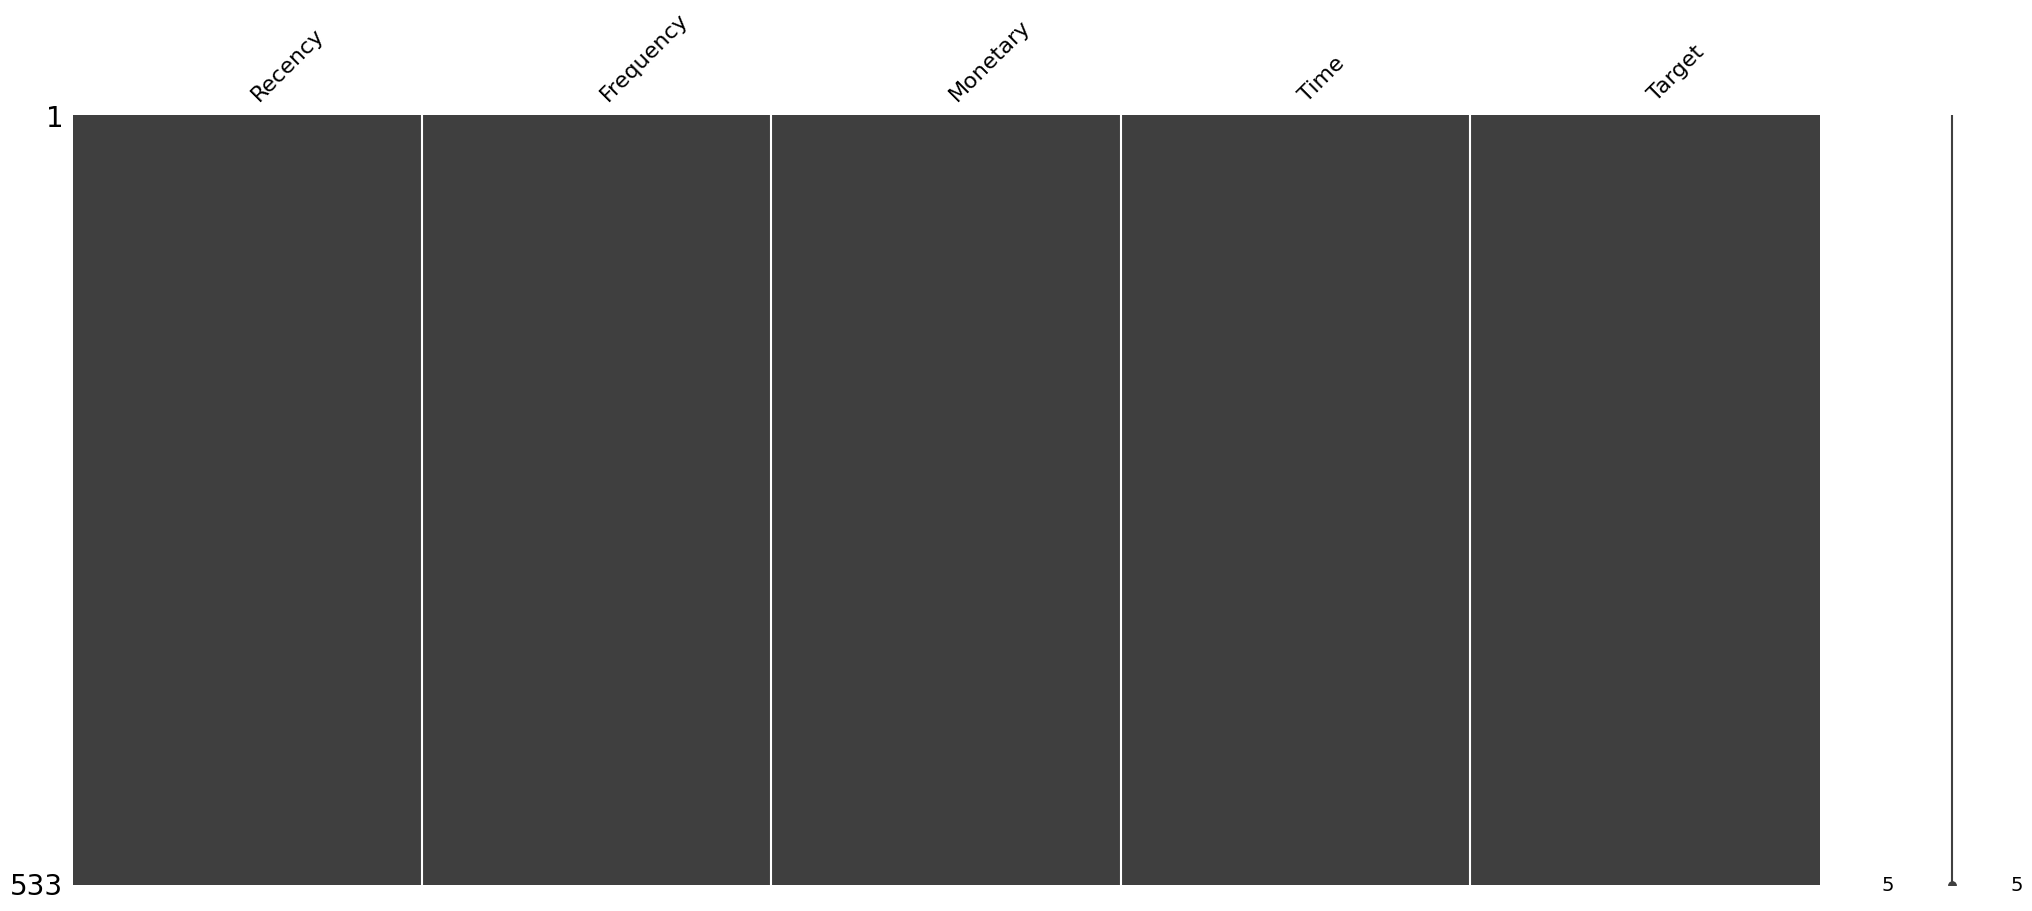

In [60]:
# 📌 결측치 시각화
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)

✅ 2.3 기초 통계량 분석
## 2.3 기초 통계량 분석

수치형 변수의 전반적인 분포를 파악하기 위해 기술통계량을 확인한다.

### 📌 주요 지표
- 평균(mean)
- 중앙값(median)
- 표준편차(std)
- 최소/최대값
- 사분위수(Q1, Q3)

이를 통해 데이터의 왜도 및 이상치 존재 가능성을 파악할 수 있다.

In [61]:
# 📌 기본 통계량
display(df.describe())

,Recency,Frequency,Monetary,Time,Target
count,533.000000,533.000000,533.000000,533.000000,533.00000
mean,9.529081,6.990619,1747.654784,42.303940,0.27955
std,8.250860,6.265875,1566.468760,23.295291,0.44920
min,0.000000,1.000000,250.000000,2.000000,0.00000
25%,3.000000,3.000000,750.000000,26.000000,0.00000
50%,8.000000,5.000000,1250.000000,38.000000,0.00000
75%,14.000000,9.000000,2250.000000,58.000000,1.00000
max,74.000000,50.000000,12500.000000,98.000000,1.00000


In [62]:
# 📌 중앙값 추가 확인
print("중앙값 (Median):")
display(df.median(numeric_only=True))

중앙값 (Median):


,0
Recency,8.0
Frequency,5.0
Monetary,1250.0
Time,38.0
Target,0.0


✅ 2.4 데이터 정제 (Cleaning)
## 2.4 데이터 정제 (Cleaning)

데이터 분석의 신뢰성을 높이기 위해 데이터 정제를 수행한다.

### 📌 수행 항목
- 중복 데이터 제거
- 데이터 타입 변환
- 이상치 탐지 및 처리

이 단계는 실제 분석보다 더 중요한 단계로, 결과의 품질을 좌우한다.

🔹 2.4.1 중복 데이터 제거

In [63]:
# 📌 중복 데이터 확인
duplicate_count = df.duplicated().sum()
print("중복 데이터 수:", duplicate_count)

# 📌 중복 제거
df = df.drop_duplicates()

print("중복 제거 후 데이터 크기:", df.shape)

중복 데이터 수: 0
중복 제거 후 데이터 크기: (533, 5)


🔹 2.4.2 데이터 타입 변환

In [64]:
# 📌 데이터 타입 재확인
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 533 entries, 0 to 747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Recency    533 non-null    int64
 1   Frequency  533 non-null    int64
 2   Monetary   533 non-null    int64
 3   Time       533 non-null    int64
 4   Target     533 non-null    int64
dtypes: int64(5)
memory usage: 25.0 KB


🔹 2.4.3 이상치(Outlier) 탐지

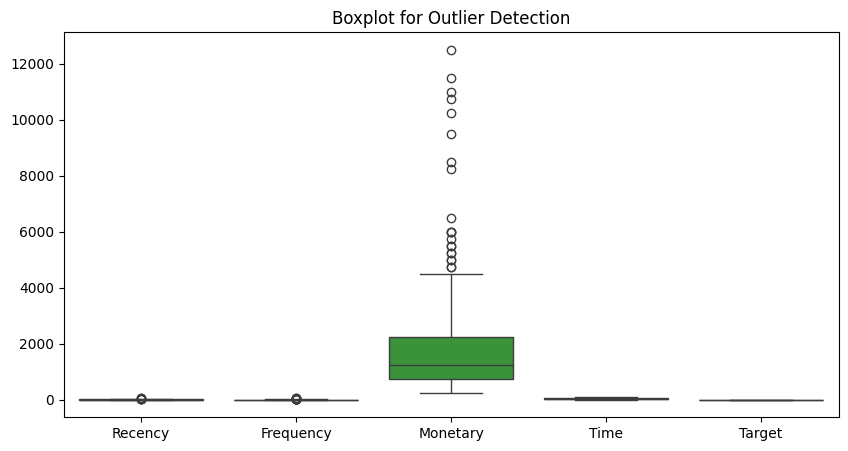

In [65]:
# 📌 박스플롯으로 이상치 확인
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.show()

🔹 2.4.4 IQR 기반 이상치 탐지

In [66]:
# 📌 IQR 기반 이상치 탐지

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

print("이상치 개수:")
display(outliers.sum())

이상치 개수:


,0
Recency,6
Frequency,21
Monetary,21
Time,0
Target,0


## 3.1 수치형 변수 분석

수치형 변수의 분포를 분석하여 데이터의 형태를 이해한다.

### 📌 분석 목적
- 데이터 분포 확인 (정규성 여부)
- 왜도(Skewness) 및 첨도(Kurtosis) 확인
- 이상치 존재 여부 탐색

### 📌 분석 방법
- 히스토그램(Histogram)
- 커널 밀도 추정(KDE)
- 왜도 및 첨도 수치 확인

🔹 3.1.1 히스토그램 + KDE

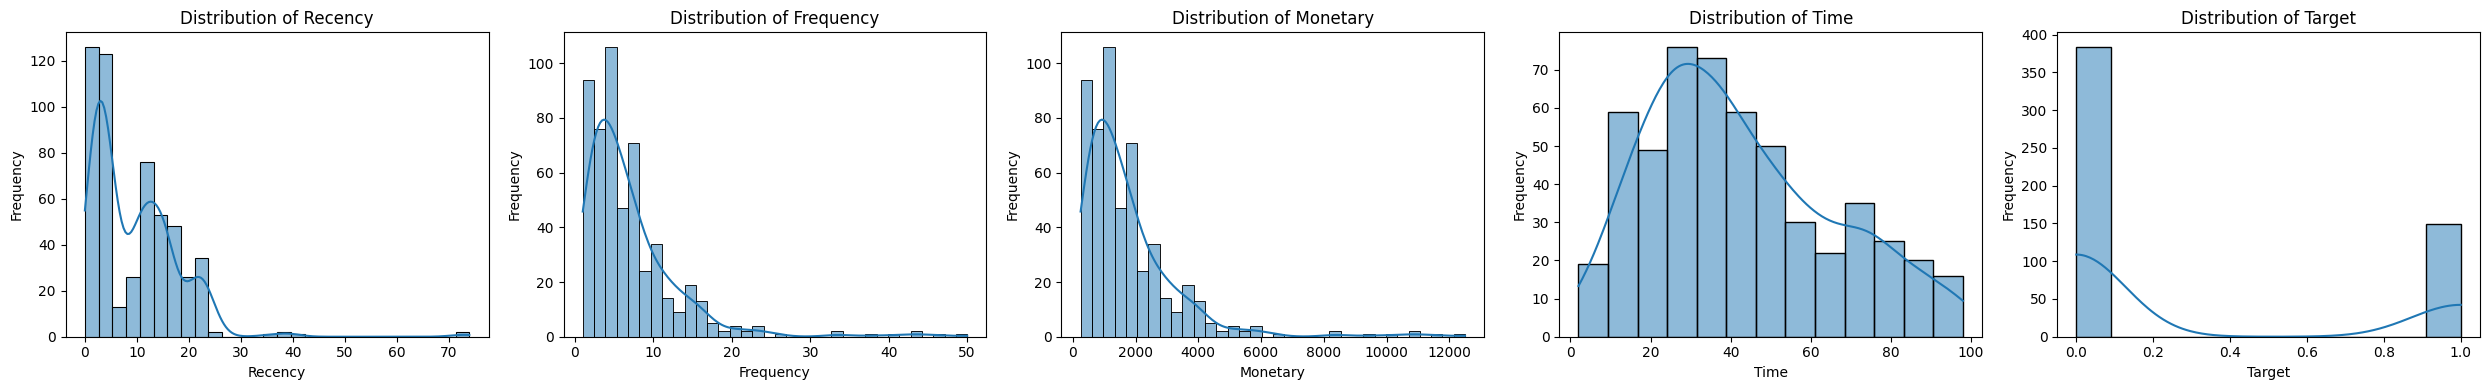

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 수치형 변수 선택
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(numeric_cols)

# 2. 서브플롯 설정 (1행 n_cols열)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4)) # 변수 개수에 따라 가로 길이 자동 조절

# 3. 반복문을 통해 각 축(ax)에 그래프 그리기
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout() # 그래프 간 간격 자동 조정
plt.show()

🔹 3.1.2 왜도(Skewness) & 첨도(Kurtosis)

In [68]:
# 📌 왜도 & 첨도 계산
skewness = df[numeric_cols].skew()
kurtosis = df[numeric_cols].kurtosis()

stats_df = pd.DataFrame({
    'Skewness': skewness,
    'Kurtosis': kurtosis
})

display(stats_df)

,Skewness,Kurtosis
Recency,2.265058,12.396828
Frequency,3.041101,13.745946
Monetary,3.041101,13.745946
Time,0.563865,-0.489369
Target,0.985222,-1.033229


### 📊 해석 기준

- **왜도 (Skewness)**
  - 0에 가까움 → 대칭 분포
  - 양수 → 오른쪽 꼬리 (right-skewed)
  - 음수 → 왼쪽 꼬리 (left-skewed)

- **첨도 (Kurtosis)**
  - 0 기준 → 정규분포와 유사
  - 양수 → 뾰족 (heavy tail)
  - 음수 → 평평 (light tail)

👉 왜곡된 변수는 로그 변환(log transform) 등을 고려할 수 있다.

✅ 3.2 범주형 변수 분석
## 3.2 범주형 변수 분석

범주형 변수의 분포를 분석하여 데이터 불균형 여부를 확인한다.

### 📌 분석 목적
- 클래스 분포 확인
- 불균형 데이터 여부 판단
- 희소 클래스(Rare class) 탐색

🔹 3.2.1 클래스 분포 확인

In [69]:
# 📌 범주형 변수 선택
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# 만약 타겟이 숫자형이면 포함
if 'Target' in df.columns:
    categorical_cols = list(categorical_cols) + ['Target']

for col in categorical_cols:
    print(f"\n📊 {col} 분포")
    display(df[col].value_counts())


📊 Target 분포


,count
Target,
0,384
1,149


🔹 3.2.2 비율 시각화

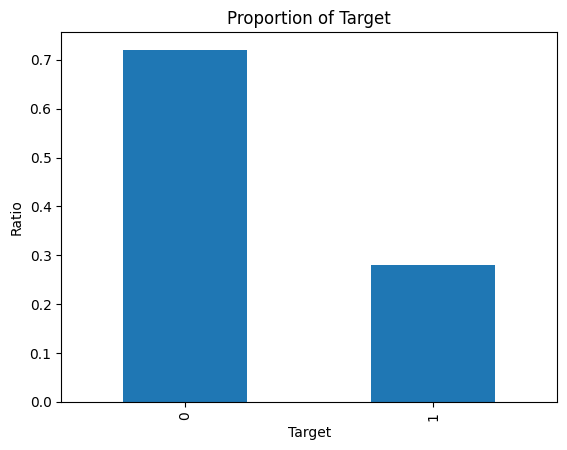

In [70]:
for col in categorical_cols:
    plt.figure()
    df[col].value_counts(normalize=True).plot(kind='bar')
    plt.title(f'Proportion of {col}')
    plt.ylabel('Ratio')
    plt.show()

### 📌 해석 포인트

- 특정 클래스가 80% 이상이면 → **불균형 데이터**
- 매우 작은 비율(<5%) → **희소 클래스(Rare Label)**

👉 모델링 시:
- 클래스 불균형 처리 필요 (Sampling, Class Weight 등)

## 3.3 파생 변수 생성 (Feature Engineering)

기존 변수를 변환하여 더 의미 있는 특징을 생성한다.

### 📌 목적
- 모델 성능 향상
- 해석력 증가
- 패턴 명확화

대표적인 방법:
- 구간화(Binning)
- 비율 생성
- 로그 변환

🔹 3.3.1 Recency 구간화 (Binning)

In [71]:
# 📌 Recency 구간화
df['Recency_bin'] = pd.cut(
    df['Recency'],
    bins=[0, 3, 6, 12, 24, 100],
    labels=['0-3', '3-6', '6-12', '12-24', '24+']
)

df['Recency_bin'].value_counts()

,count
Recency_bin,
12-24,166
0-3,134
3-6,115
6-12,105
24+,8


🔹 3.3.2 Frequency 구간화

In [72]:
df['Frequency_bin'] = pd.cut(
    df['Frequency'],
    bins=[0, 5, 10, 20, 50],
    labels=['0-5', '5-10', '10-20', '20+']
)

df['Frequency_bin'].value_counts()

,count
Frequency_bin,
0-5,276
5-10,154
10-20,86
20+,17


🔹 3.3.3 파생 변수 시각화

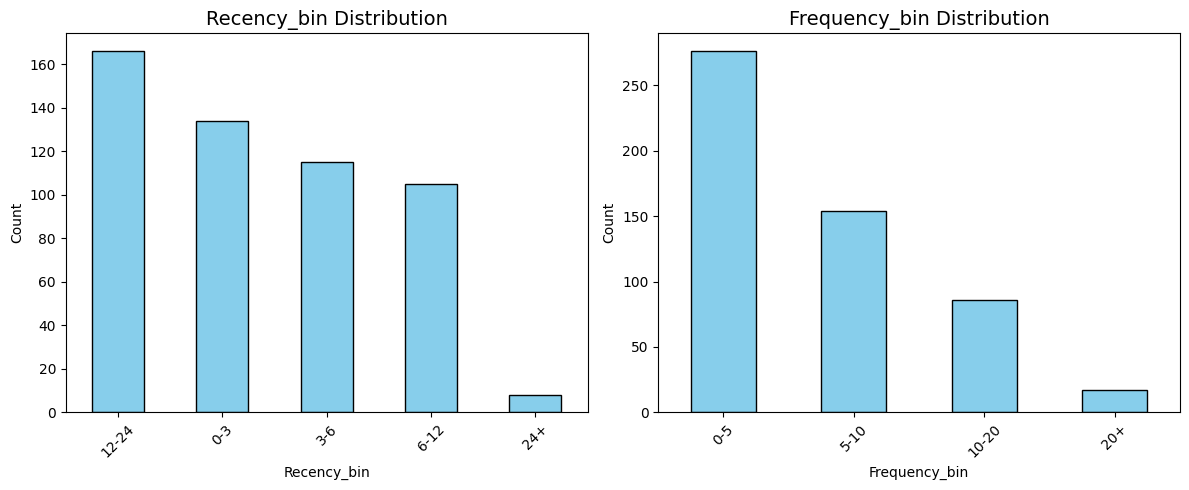

In [73]:
import matplotlib.pyplot as plt

# 1. 서브플롯 설정 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2. 리스트와 인덱스를 활용해 반복문 실행
bin_cols = ['Recency_bin', 'Frequency_bin']

for i, col in enumerate(bin_cols):
    # 각 컬럼의 데이터 빈도수를 계산하여 해당 축(axes[i])에 그리기
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')

    axes[i].set_title(f'{col} Distribution', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45) # 라벨이 길 경우 45도 회전

# 3. 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

## 4.1 수치형 변수 간 상관관계 분석

변수 간의 선형 관계를 파악하기 위해 상관계수를 분석한다.

### 📌 분석 목적
- 변수 간 관계 강도 파악
- 다중공선성(Multicollinearity) 확인
- 중요한 변수 후보 탐색

### 📌 방법
- 상관계수 행렬 (Correlation Matrix)
- 히트맵 시각화

🔹 4.1.1 상관계수 계산

In [74]:
# 📌 수치형 변수 선택
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 📌 상관계수 행렬
corr_matrix = df[numeric_cols].corr()

display(corr_matrix)

,Recency,Frequency,Monetary,Time,Target
Recency,1.000000,-0.212165,-0.212165,0.143196,-0.274799
Frequency,-0.212165,1.000000,1.000000,0.555731,0.174570
Monetary,-0.212165,1.000000,1.000000,0.555731,0.174570
Time,0.143196,0.555731,0.555731,1.000000,-0.134236
Target,-0.274799,0.174570,0.174570,-0.134236,1.000000


🔹 4.1.2 히트맵 시각화

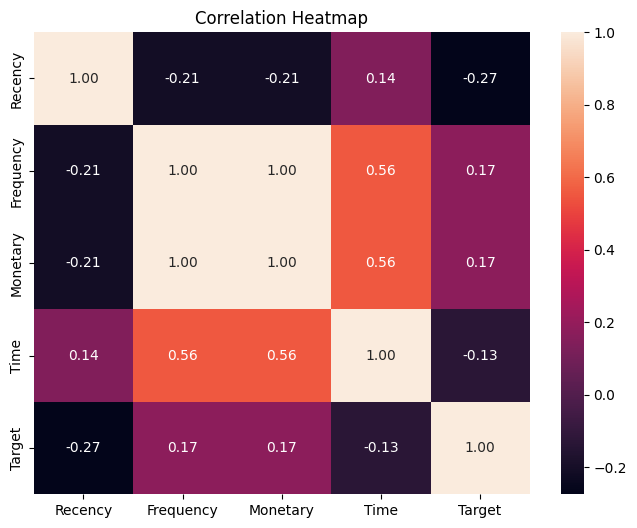

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### 📌 해석 포인트

- 0.7 이상 → 강한 양의 상관관계
- -0.7 이하 → 강한 음의 상관관계
- 0에 가까움 → 관계 약함

👉 높은 상관 변수는:
- 중복 정보 가능성
- 모델에서 제거 또는 선택 필요

✅ 4.2 타겟 변수 기반 분석
## 4.2 타겟 변수 기반 분석

타겟 변수에 따라 독립 변수의 분포가 어떻게 달라지는지 분석한다.

### 📌 분석 목적
- 변수별 영향력 탐색
- 타겟 분류 기준 확인

🔹 4.2.1 Box Plot 분석

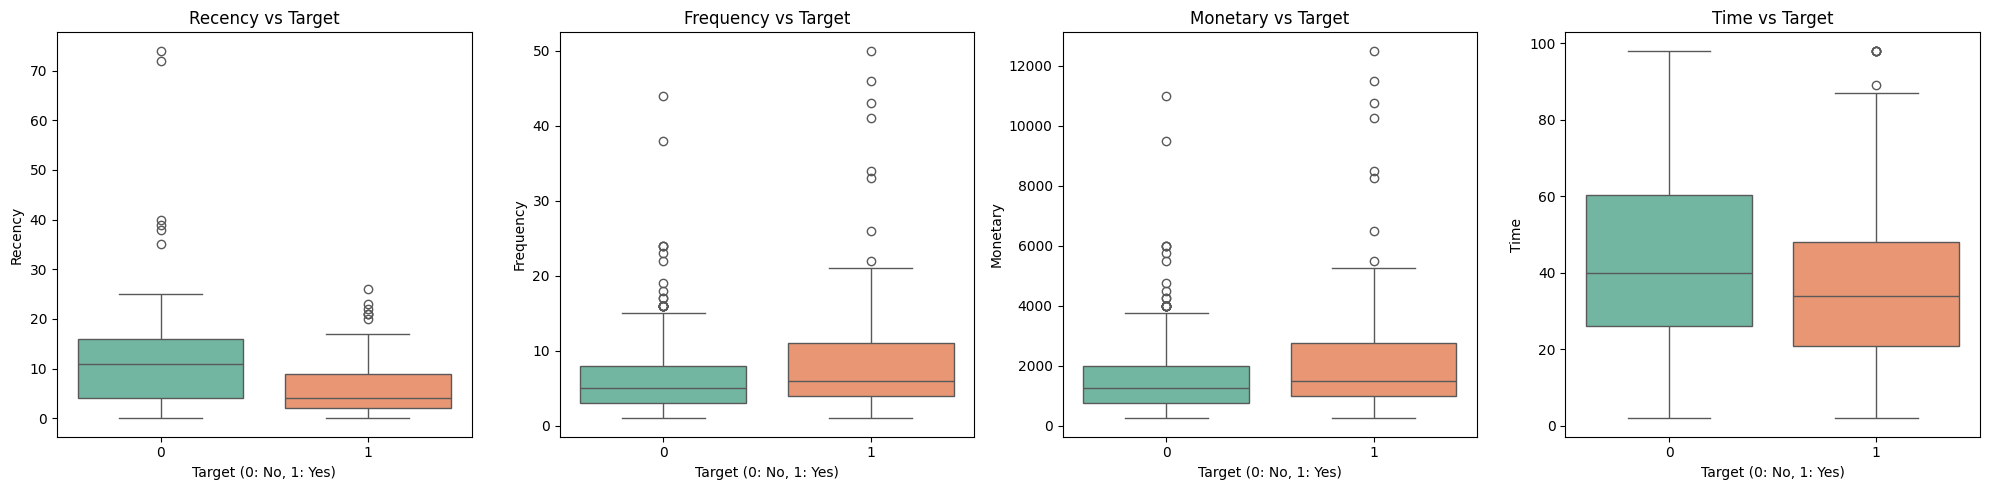

In [76]:
# 📌 타겟 변수 존재 가정

# 1. 타겟을 제외한 분석할 수치형 변수 추출
features = [col for col in numeric_cols if col != 'Target']
n_features = len(features)

# 2. 서브플롯 설정 (1행 n_features열)
fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 5))

# 3. 반복문을 통해 각 축(ax)에 Boxplot 그리기
for i, col in enumerate(features):
    sns.boxplot(x='Target', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Target', fontsize=12)
    axes[i].set_xlabel('Target (0: No, 1: Yes)')
    axes[i].set_ylabel(col)

# 4. 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

🔹 4.2.2 Violin Plot 분석

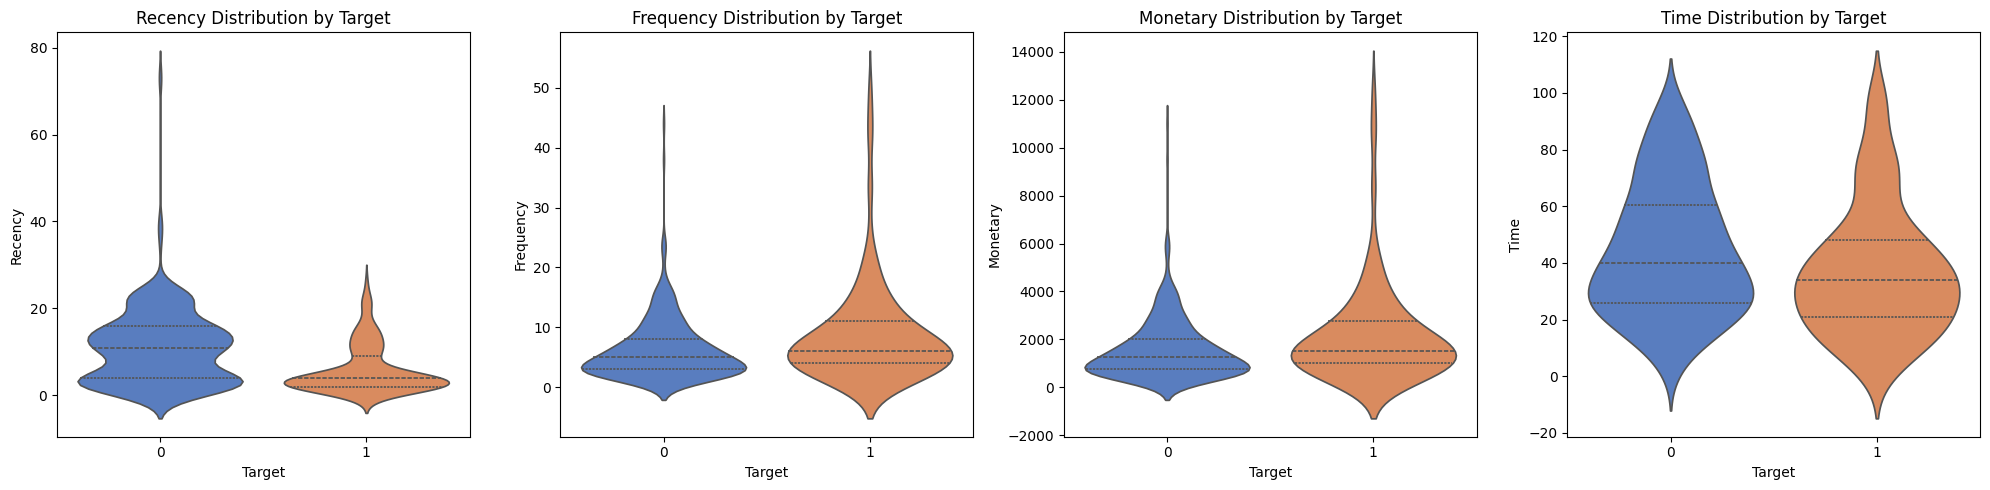

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 타겟을 제외한 수치형 변수 리스트 생성
features = [col for col in numeric_cols if col != 'Target']
n_features = len(features)

# 2. 서브플롯 설정 (1행 n_features열)
fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 5))

# 3. 반복문을 통해 각 축(ax)에 Violin Plot 그리기
for i, col in enumerate(features):
    sns.violinplot(x='Target', y=col, data=df, ax=axes[i], palette='muted', inner='quartile')
    axes[i].set_title(f'{col} Distribution by Target', fontsize=12)
    axes[i].set_xlabel('Target')
    axes[i].set_ylabel(col)

# 4. 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

### 📌 해석 포인트

- 그룹 간 중앙값 차이 → 영향력 존재
- 분포 형태 차이 → 패턴 존재
- 분산 차이 → 안정성 차이

👉 차이가 큰 변수 = 중요한 Feature 후보

✅ 4.3 변수 간 관계 (Scatter Plot)
## 4.3 변수 간 관계 분석 (Scatter Plot)

두 변수 간의 관계를 시각적으로 확인한다.

### 📌 분석 목적
- 선형 / 비선형 관계 확인
- 군집 패턴 탐색

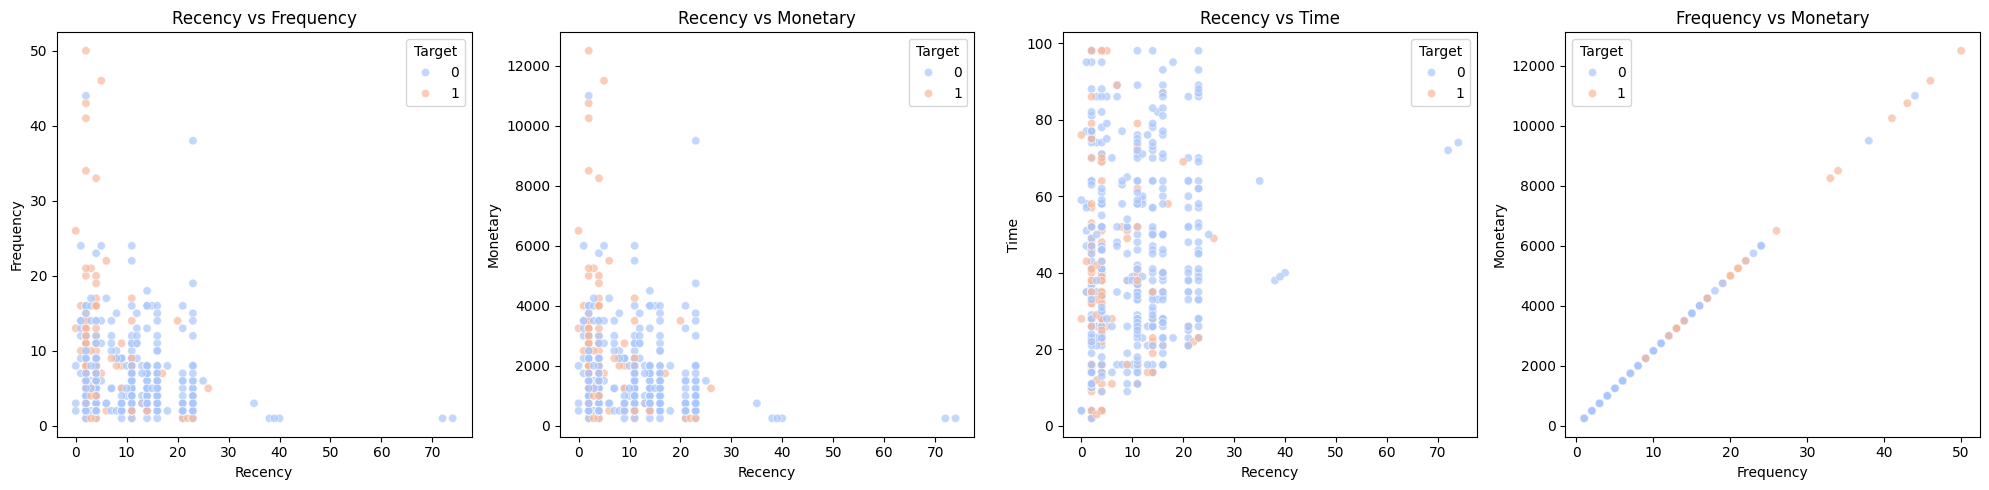

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# 1. 분석할 변수 쌍 생성 (Target 제외)
features = [col for col in numeric_cols if col != 'Target']
pairs = list(itertools.combinations(features, 2))

# 2. 시각화할 쌍의 개수 설정 (예: 상위 4개)
n_pairs = min(len(pairs), 4)
fig, axes = plt.subplots(1, n_pairs, figsize=(5 * n_pairs, 5))

# 3. 반복문을 통해 각 축(ax)에 Scatter Plot 그리기
for i in range(n_pairs):
    x_col, y_col = pairs[i]
    sns.scatterplot(data=df, x=x_col, y=y_col, hue='Target', ax=axes[i], palette='coolwarm', alpha=0.7)
    axes[i].set_title(f'{x_col} vs {y_col}', fontsize=12)

# 4. 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

🔹 4.3.2 Pairplot (전체 관계)

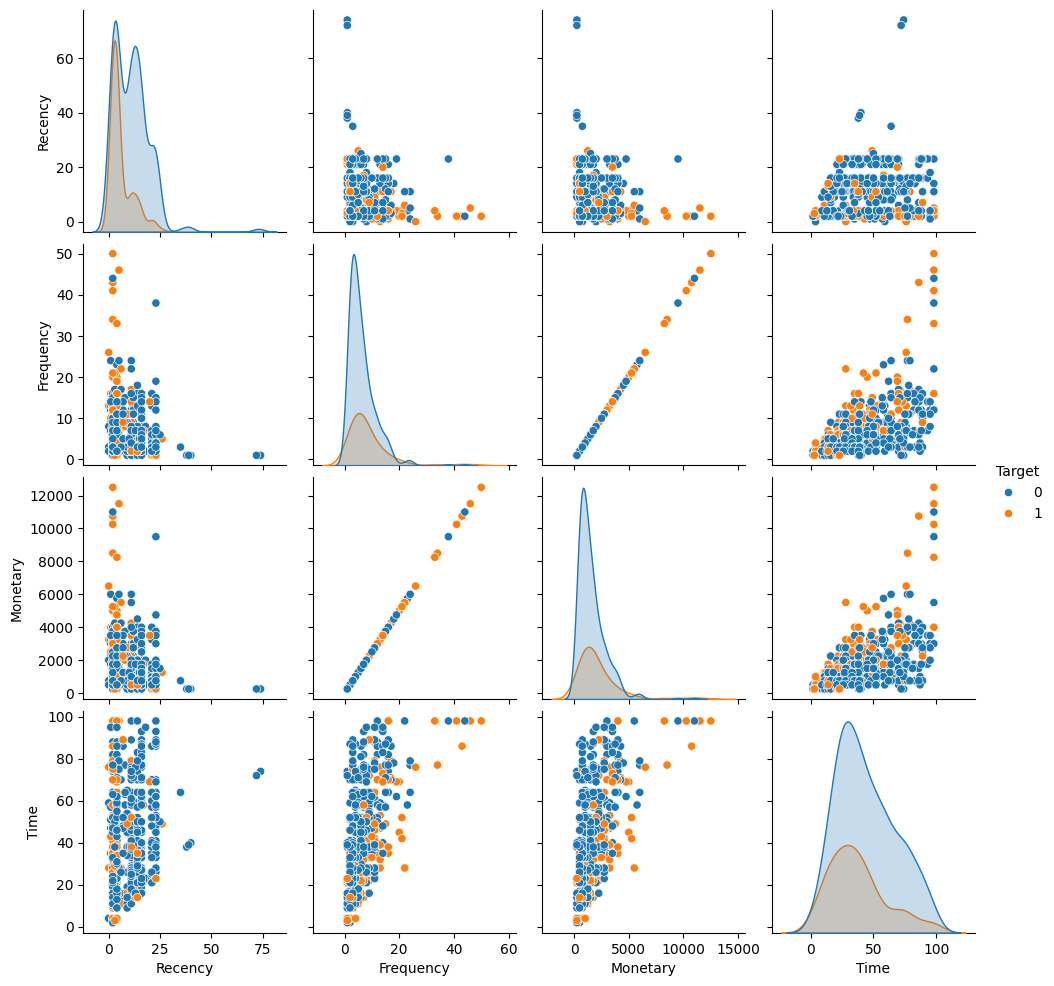

In [79]:
sns.pairplot(df[numeric_cols], hue='Target')
plt.show()

✅ 4.4 세그먼트 비교 분석
## 4.4 세그먼트 비교 분석

특정 기준으로 데이터를 그룹화하여 행동 패턴 차이를 분석한다.

### 📌 예시
- Recency 기준 그룹
- Frequency 기준 그룹

🔹 4.4.1 Recency 그룹별 타겟 비율

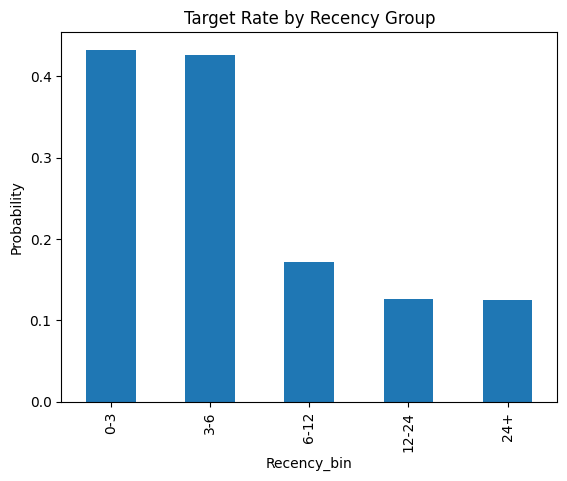

In [80]:
# 그룹별 타겟 평균 (재헌혈 비율)
recency_group = df.groupby('Recency_bin')['Target'].mean()

recency_group.plot(kind='bar')
plt.title('Target Rate by Recency Group')
plt.ylabel('Probability')
plt.show()

🔹 4.4.2 Frequency 그룹별 타겟 비율

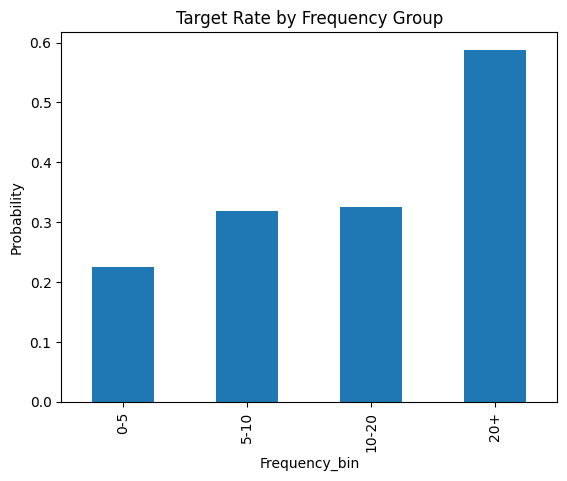

In [81]:
freq_group = df.groupby('Frequency_bin')['Target'].mean()

freq_group.plot(kind='bar')
plt.title('Target Rate by Frequency Group')
plt.ylabel('Probability')
plt.show()

### 📌 해석 포인트

- 특정 그룹에서 타겟 비율이 높다 → 핵심 고객군
- 패턴이 명확하다 → 예측 가능성 높음

👉 이 결과는 마케팅 전략 및 모델링에 직접 활용 가능

## 5.1 주요 패턴 발견

EDA를 통해 다음과 같은 주요 패턴을 확인할 수 있다.

### 📊 핵심 인사이트

1. **Recency (최근성)**
   - 최근에 헌혈한 사람일수록 재헌혈 확률이 높음
   - 시간이 지날수록 재헌혈 확률 감소

2. **Frequency (헌혈 횟수)**
   - 헌혈 횟수가 많을수록 재헌혈 가능성이 높음
   - 반복 행동 패턴이 존재

3. **Time (헌혈 기간)**
   - 장기간 헌혈한 사람일수록 안정적인 헌혈자
   - 충성도 높은 그룹 존재

4. **변수 관계**
   - Frequency와 Monetary는 강한 양의 상관관계
   - 일부 변수 간 다중공선성 가능성 존재

---

### 📌 핵심 요약

👉 “최근 + 자주 + 오래” 헌혈한 사람이  
👉 미래에도 헌혈할 가능성이 가장 높다

## 5.2 가설 검증 결과

1장에서 설정한 가설을 기반으로 검증 결과를 정리한다.

---

### 📌 가설 검증 결과

| 가설 | 내용 | 결과 |
|------|------|------|
| H1 | Recency가 낮을수록 재헌혈 확률 증가 | ✅ 채택 |
| H2 | Frequency가 높을수록 재헌혈 확률 증가 | ✅ 채택 |
| H3 | Time이 길수록 헌혈 지속성 증가 | ✅ 채택 |

---

### 📌 해석

- 모든 가설이 데이터에서 유의미하게 확인됨
- 특히 Recency와 Frequency는 매우 강력한 예측 변수
- 향후 모델링 시 핵심 Feature로 활용 가능

✅ 5.2 (코드) 가설 검증 보조

In [82]:
# 📌 그룹 간 평균 비교 (간단 검증)

print("Recency 영향:")
display(df.groupby('Recency_bin')['Target'].mean())

print("\nFrequency 영향:")
display(df.groupby('Frequency_bin')['Target'].mean())

Recency 영향:


,Target
Recency_bin,
0-3,0.432836
3-6,0.426087
6-12,0.171429
12-24,0.126506
24+,0.125000



Frequency 영향:


,Target
Frequency_bin,
0-5,0.224638
5-10,0.318182
10-20,0.325581
20+,0.588235


✅ 5.3 예상치 못한 발견 (Unexpected Findings)
## 5.3 예상치 못한 발견 (Unexpected Findings)

EDA 과정에서 초기 가설과 다르게 나타난 흥미로운 패턴은 다음과 같다.

### 🔍 발견 내용

1. 일부 구간에서 Recency가 낮아도 재헌혈 확률이 낮은 경우 존재
   → 단순 시간 요소 외 다른 변수 영향 가능

2. Frequency가 높은 그룹 내에서도 편차 존재
   → 헌혈 행동이 일정하지 않은 사용자 존재

3. 이상치 데이터 일부 발견
   → 특정 헌혈량(Monetary)이 비정상적으로 높은 값 존재

---

### 📌 시사점

- 단일 변수로 설명되지 않는 복합 패턴 존재
- 다변량 모델 필요성 증가
- Feature Engineering 중요성 확인

In [83]:
df

,Recency,Frequency,Monetary,Time,Target,Recency_bin,Frequency_bin
0,2,50,12500,98,1,0-3,20+
1,0,13,3250,28,1,NaN,10-20
2,1,16,4000,35,1,0-3,10-20
3,2,20,5000,45,1,0-3,10-20
4,1,24,6000,77,0,0-3,20+
...,...,...,...,...,...,...,...
743,23,2,500,38,0,12-24,0-5
744,21,2,500,52,0,12-24,0-5
745,23,3,750,62,0,12-24,0-5
746,39,1,250,39,0,24+,0-5
